Below is an example of training a simple neural network to fit the function $f(\mathbf{x})$,

$$
f(\mathbf{x}) = \sin(x) + 2\cos(x)
$$

In [534]:
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt

device = torch.device("cpu")
# add generator for consistency between runs
gen = torch.Generator(device=device).manual_seed(1)

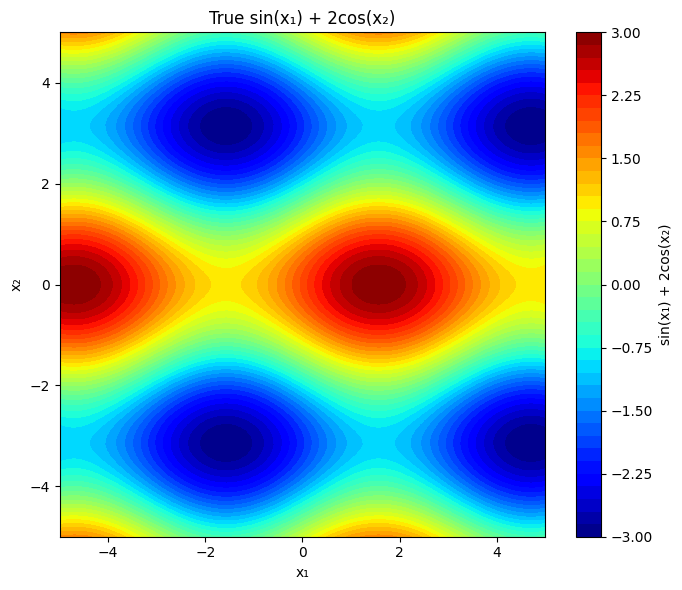

In [535]:
# True function
points_per_dim = 100

linx1 = torch.linspace(-5, 5, points_per_dim)
linx2 = torch.linspace(-5, 5, points_per_dim)
x1, x2 = torch.meshgrid(linx1, linx2, indexing='ij')

z = torch.sin(x1) + 2 * torch.cos(x2)

plt.figure(figsize=(7, 6))
plt.contourf(x1.numpy(), x2.numpy(), z.numpy(), levels=50, cmap='jet')
plt.colorbar(label='sin(x₁) + 2cos(x₂)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('True sin(x₁) + 2cos(x₂)')
plt.tight_layout()
plt.show()


In [536]:
# Layer 0 (input layer)
# N x D
# we are using row vectors
n_samples = 200
x_train = torch.rand(n_samples, 2, generator=gen) * 10 - 5  # uniform in [-5, 5]

In [537]:
# layer 1
layer1_weights = torch.randn((3, 2), requires_grad=True, generator=gen)
layer1_bias = torch.randn(3, requires_grad=True, generator=gen)
layer1_z = x_train @ layer1_weights.T + layer1_bias
layer1_a = F.tanh(layer1_z)
layer1_a.shape


torch.Size([200, 3])

In [538]:
# layer 2
layer2_weights = torch.randn((4, 3), requires_grad=True, generator=gen)
layer2_bias = torch.randn(4, requires_grad=True, generator=gen)
layer2_z = layer1_a @ layer2_weights.T + layer2_bias
layer2_a = F.tanh(layer2_z)
layer2_a.shape

torch.Size([200, 4])

In [539]:
# layer 3 (Output Layer)
layer3_weights = torch.randn((1, 4), requires_grad=True, generator=gen)
layer3_bias = torch.randn(1, requires_grad=True, generator=gen)
predicted = layer2_a @ layer3_weights.T + layer3_bias
predicted.shape

torch.Size([200, 1])

In [540]:
# Loss function
y_train = torch.sin(x_train[:, 0]) + 2 * torch.cos(x_train[:, 1])  # shape (n_samples,)
y_train = y_train.unsqueeze(1) # shape (n_samples, 1)

loss = torch.sum((predicted - y_train)**2) / n_samples

loss

tensor(4.2733, grad_fn=<DivBackward0>)

In [541]:
# gradient check against torch

delta_output_layer = (2 / n_samples) * (predicted - y_train)
grad_W3 = delta_output_layer.T @ layer2_a
grad_b3 = torch.sum(delta_output_layer, dim=0)
delta_a2 = (delta_output_layer @ layer3_weights) * (1-torch.tanh(layer2_z)**2)
grad_W2 = delta_a2.T @ layer1_a
grad_b2 = torch.sum(delta_a2, dim=0)
delta_a1 = (delta_a2 @ layer2_weights) * (1-torch.tanh(layer1_z)**2)
grad_W1 = delta_a1.T @ x_train
grad_b1 = torch.sum(delta_a1, dim=0)

In [542]:
print("Manual backpropagation")
print("Layer 3")
print(grad_W3)
print(grad_b3)

print("Layer 2")
print(grad_W2)
print(grad_b2)

print("Layer 1")
print(grad_W1)
print(grad_b1)

Manual backpropagation
Layer 3
tensor([[ 1.2829,  2.5972, -0.2416, -1.2356]], grad_fn=<MmBackward0>)
tensor([-0.2651], grad_fn=<SumBackward1>)
Layer 2
tensor([[ 0.0944,  0.1553, -0.1439],
        [ 0.1846,  0.2517, -0.1603],
        [-0.0291, -0.0411,  0.0241],
        [ 0.5482,  1.2588, -1.0721]], grad_fn=<MmBackward0>)
tensor([-0.0925, -0.1232,  0.0201, -0.3340], grad_fn=<SumBackward1>)
Layer 1
tensor([[ 2.5806,  2.4020],
        [ 0.0512, -0.0794],
        [-0.0553,  0.0559]], grad_fn=<MmBackward0>)
tensor([ 0.2152, -0.1233,  0.2022], grad_fn=<SumBackward1>)


In [543]:
# torch gradients
loss.backward()

In [544]:
print("Torch backpropagation")
print("Layer 3")
print(layer3_weights.grad)
print(layer3_bias.grad)

print("Layer 2")
print(layer2_weights.grad)
print(layer2_bias.grad)

print("Layer 1")
print(layer1_weights.grad)
print(layer1_bias.grad)

Torch backpropagation
Layer 3
tensor([[ 1.2829,  2.5972, -0.2416, -1.2356]])
tensor([-0.2651])
Layer 2
tensor([[ 0.0944,  0.1553, -0.1439],
        [ 0.1846,  0.2517, -0.1603],
        [-0.0291, -0.0411,  0.0241],
        [ 0.5482,  1.2588, -1.0721]])
tensor([-0.0925, -0.1232,  0.0201, -0.3340])
Layer 1
tensor([[ 2.5806,  2.4020],
        [ 0.0512, -0.0794],
        [-0.0553,  0.0559]])
tensor([ 0.2152, -0.1233,  0.2022])


In [545]:
# training loop

LR = 0.3

with torch.no_grad():
    for i in range(10000):

        # forward pass (must recompute each iteration with updated weights)
        layer1_z = x_train @ layer1_weights.T + layer1_bias
        layer1_a = F.tanh(layer1_z)
        layer2_z = layer1_a @ layer2_weights.T + layer2_bias
        layer2_a = F.tanh(layer2_z)
        predicted = layer2_a @ layer3_weights.T + layer3_bias

        # current loss
        loss = torch.sum((predicted - y_train)**2) / n_samples
        print(f"Iteration: {i}, loss: {loss}")

        # backpropagation to find gradients
        delta_output_layer = (2 / n_samples) * (predicted - y_train)
        grad_W3 = delta_output_layer.T @ layer2_a
        grad_b3 = torch.sum(delta_output_layer, dim=0)
        delta_a2 = (delta_output_layer @ layer3_weights) * (1-torch.tanh(layer2_z)**2)
        grad_W2 = delta_a2.T @ layer1_a
        grad_b2 = torch.sum(delta_a2, dim=0)
        delta_a1 = (delta_a2 @ layer2_weights) * (1-torch.tanh(layer1_z)**2)
        grad_W1 = delta_a1.T @ x_train
        grad_b1 = torch.sum(delta_a1, dim=0)

        # go against gradient of parameters because we want to minimize loss
        layer3_weights -= LR * grad_W3
        layer3_bias -= LR * grad_b3

        layer2_weights -= LR * grad_W2
        layer2_bias -= LR * grad_b2

        layer1_weights -= LR * grad_W1
        layer1_bias -= LR * grad_b1

Iteration: 0, loss: 4.273297309875488
Iteration: 1, loss: 2.4087204933166504
Iteration: 2, loss: 2.2429943084716797
Iteration: 3, loss: 2.1515674591064453
Iteration: 4, loss: 2.0664165019989014
Iteration: 5, loss: 1.9761451482772827
Iteration: 6, loss: 1.8954178094863892
Iteration: 7, loss: 1.8313370943069458
Iteration: 8, loss: 1.7806837558746338
Iteration: 9, loss: 1.7405917644500732
Iteration: 10, loss: 1.7091058492660522
Iteration: 11, loss: 1.6840835809707642
Iteration: 12, loss: 1.6635198593139648
Iteration: 13, loss: 1.6462225914001465
Iteration: 14, loss: 1.6322555541992188
Iteration: 15, loss: 1.624060869216919
Iteration: 16, loss: 1.6342060565948486
Iteration: 17, loss: 1.6658291816711426
Iteration: 18, loss: 1.8040510416030884
Iteration: 19, loss: 1.7200320959091187
Iteration: 20, loss: 1.8380100727081299
Iteration: 21, loss: 1.6752511262893677
Iteration: 22, loss: 1.6965218782424927
Iteration: 23, loss: 1.619333028793335
Iteration: 24, loss: 1.6491546630859375
Iteration: 25

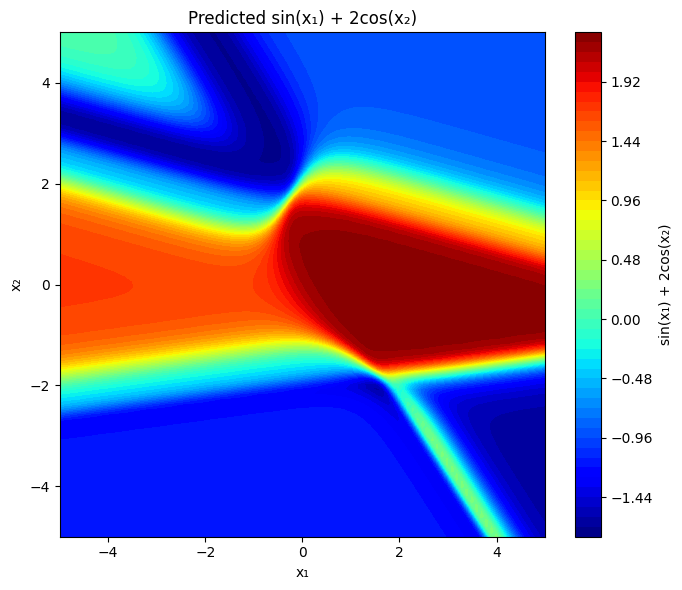

In [546]:




linx1_test = torch.linspace(-5, 5, points_per_dim)
linx2_test = torch.linspace(-5, 5, points_per_dim)
x1, x2 = torch.meshgrid(linx1_test, linx2_test, indexing='ij')
grid_input = torch.stack([x1.flatten(), x2.flatten()], dim=1)

with torch.no_grad():
    layer1_z = grid_input @ layer1_weights.T + layer1_bias
    layer1_a = F.tanh(layer1_z)

    layer2_z = layer1_a @ layer2_weights.T + layer2_bias
    layer2_a = F.tanh(layer2_z)

    predicted = layer2_a @ layer3_weights.T + layer3_bias

    predicted = predicted.reshape(points_per_dim, points_per_dim)

plt.figure(figsize=(7, 6))
plt.contourf(x1.numpy(), x2.numpy(), predicted.numpy(), levels=50, cmap='jet')
plt.colorbar(label='sin(x₁) + 2cos(x₂)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Predicted sin(x₁) + 2cos(x₂)')
plt.tight_layout()
plt.show()
